Fáza 2 - Predspracovanie údajov

In [32]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, QuantileTransformer, RobustScaler, Normalizer

path = Path("../data/cleaned_data")

observation_df = pd.read_csv(path / "observation.csv")
patient_df = pd.read_csv(path / "patient.csv")
station_df = pd.read_csv(path / "station.csv")

In [33]:
merged_df = pd.merge(
    observation_df,
    station_df,
    on=["latitude", "longitude"],
    how="left"
)

print("Non-null station data:", merged_df['station'].notna().mean() * 100, "%")


display(merged_df.head())

Non-null station data: 100.0 %


,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,O₂ extraction ratio,SNR,oximetry,latitude,longitude,station,QoS,revision,continent,city
0,96.491498,75.410035,11.966950,14.781380,38.814201,60.447244,130.452955,97.686382,34.718865,8.254118,...,0.286386,26.305034,1.0,6.84019,79.87116,Dehiwala-Mount Lavinia,maintenance,2016-08-03,Asia,Colombo
1,97.657620,90.314511,9.500074,16.118786,42.528828,60.183638,106.651627,107.891610,36.720399,9.514584,...,0.257752,28.282578,1.0,-29.29750,-51.50361,Carlos Barbosa,good,2024-12-31,America,Sao_Paulo
2,96.528162,79.127147,11.268005,15.921648,41.262696,76.905716,131.520657,109.488301,36.720399,10.435298,...,0.255257,34.529833,1.0,9.33370,122.86370,Santa Catalina,good,2024-08-26,Asia,Manila
3,98.195660,83.015909,14.140633,14.443310,40.283494,59.027420,144.702141,101.915115,34.855279,8.896198,...,0.255097,36.136759,1.0,33.54428,-84.23381,Stockbridge,acceptable,2024-07-15,America,New_York
4,97.573527,83.388999,9.058458,17.513347,39.844401,49.965222,111.977370,98.441554,36.720399,7.009457,...,0.286358,23.648813,1.0,50.80019,7.20769,Siegburg,maintenance,2024-06-12,Europe,Berlin


In [42]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in merged_df.columns:
    if merged_df[col].dtype == "object":
        merged_df[col] = merged_df[col].fillna("Missing")
        merged_df[col] = le.fit_transform(merged_df[col].astype(str))

# --- 3️⃣ Замена NaN на 0 ---
merged_df = merged_df.fillna(0)

print("\n✅ All string columns encoded.")
print("Dataset shape:", merged_df.shape)
display(merged_df.head())

merged_df.to_csv("merged_encoded.csv", index=False)
print("💾 Saved merged_encoded.csv successfully.")


✅ All string columns encoded.
Dataset shape: (21575, 28)


,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,O₂ extraction ratio,SNR,oximetry,latitude,longitude,station,QoS,revision,continent,city
0,96.491498,75.410035,11.966950,14.781380,38.814201,60.447244,130.452955,97.686382,34.718865,8.254118,...,0.286386,26.305034,1.0,6.84019,79.87116,108,3,56,4,26
1,97.657620,90.314511,9.500074,16.118786,42.528828,60.183638,106.651627,107.891610,36.720399,9.514584,...,0.257752,28.282578,1.0,-29.29750,-51.50361,75,2,636,1,107
2,96.528162,79.127147,11.268005,15.921648,41.262696,76.905716,131.520657,109.488301,36.720399,10.435298,...,0.255257,34.529833,1.0,9.33370,122.86370,396,2,616,4,73
3,98.195660,83.015909,14.140633,14.443310,40.283494,59.027420,144.702141,101.915115,34.855279,8.896198,...,0.255097,36.136759,1.0,33.54428,-84.23381,439,0,604,1,84
4,97.573527,83.388999,9.058458,17.513347,39.844401,49.965222,111.977370,98.441554,36.720399,7.009457,...,0.286358,23.648813,1.0,50.80019,7.20769,417,3,598,6,15


💾 Saved merged_encoded.csv successfully.


to-do
- нужно взять две другие таблицы привести все их памаметры в нумерицки и соединить их с обзервашон

In [35]:
#тут уже придется использовать не обзервацию, а соединеную тублицу

X = observation_df.drop('oximetry', axis=1)
y = observation_df['oximetry']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(9706, 22) (2427, 22)


/var/folders/xz/3v1v24g13cz6t_6ww4mc5vzw0000gn/T/ipykernel_86456/190145934.py:30: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/frtndmd/Desktop/iau_Kosharova_Oliinyk_67/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


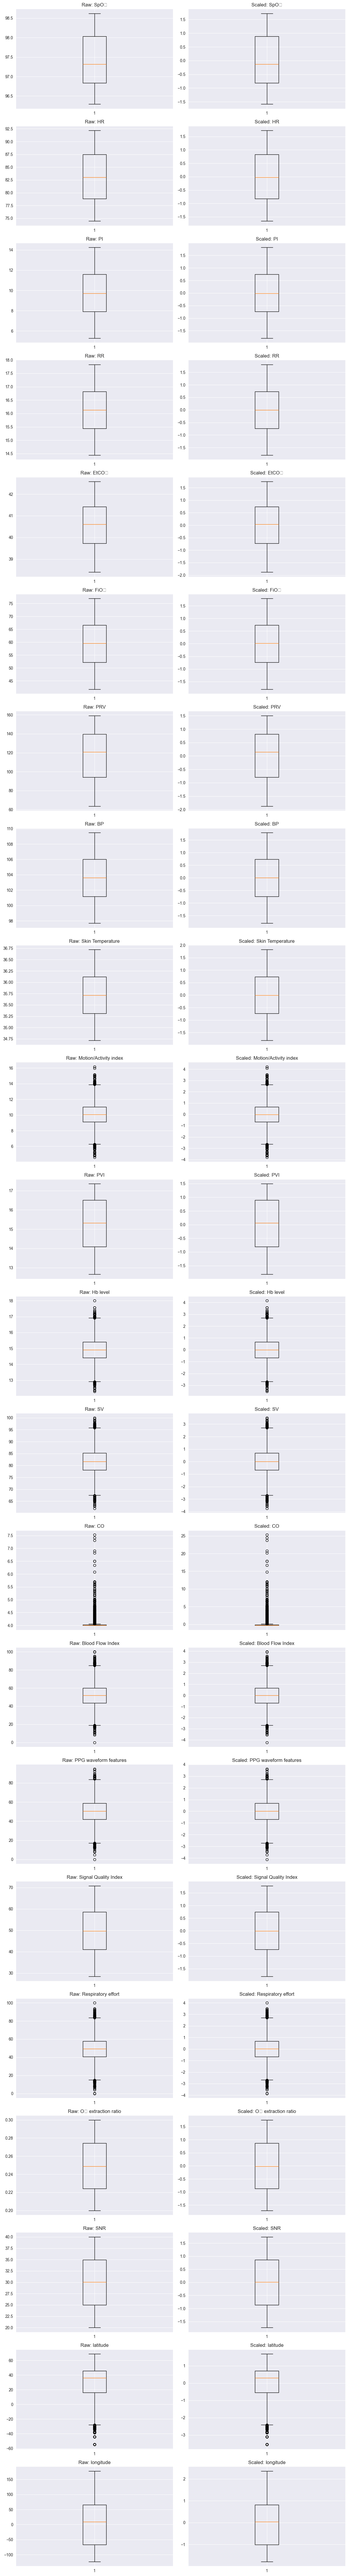

In [36]:
from math import ceil

std_scaler = StandardScaler()
std_scaler.fit(X_train)
X_train_std = std_scaler.transform(X_train)

# Преобразуем обратно в DataFrame, чтобы сохранить имена колонок
X_train_std_df = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)

n_features = X_train.shape[1]
n_plots = n_features * 2  # для raw и scaled каждого признака
n_cols = 2
n_rows = ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.ravel()  # удобная одномерная индексация

for i, col in enumerate(X_train.columns):

    axes[2 * i].boxplot(X_train[col])
    axes[2 * i].set_title(f"Raw: {col}")

    axes[2 * i + 1].boxplot(X_train_std_df[col])
    axes[2 * i + 1].set_title(f"Scaled: {col}")

# Если остались лишние пустые оси (когда n_plots < n_rows*n_cols), скрыть их
for j in range(2 * n_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


/var/folders/xz/3v1v24g13cz6t_6ww4mc5vzw0000gn/T/ipykernel_86456/2681038860.py:32: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/frtndmd/Desktop/iau_Kosharova_Oliinyk_67/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


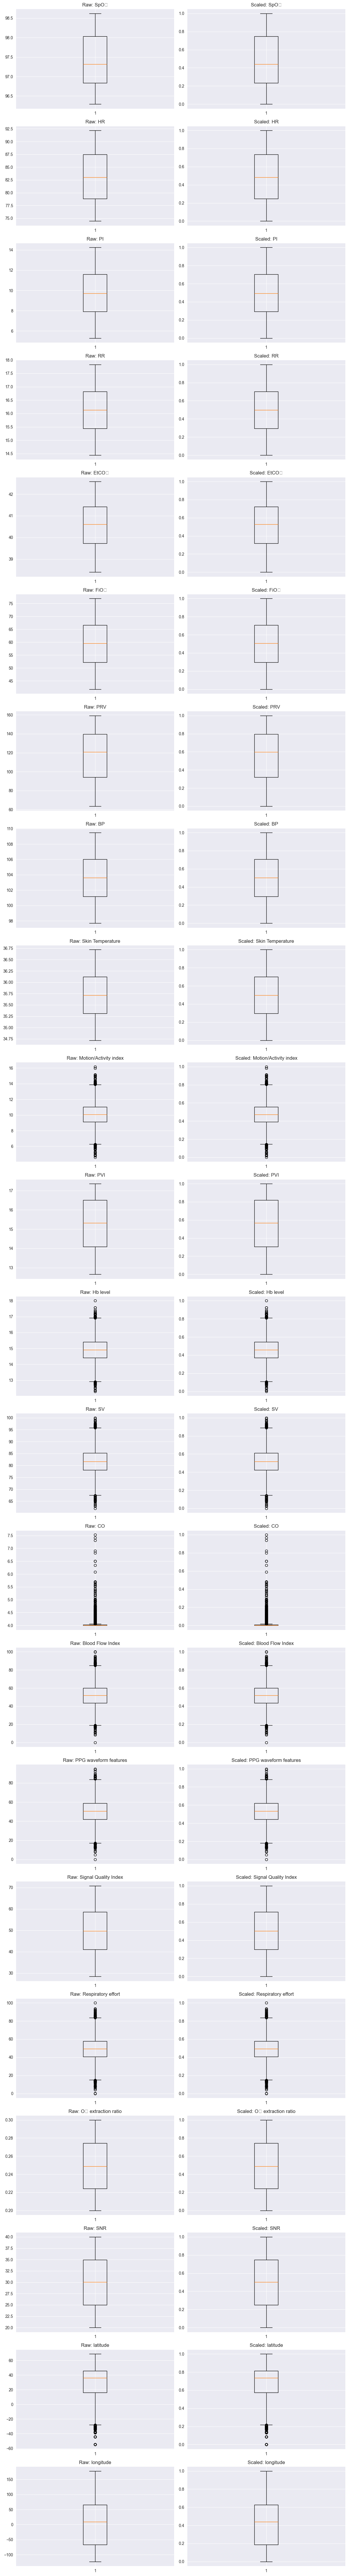

In [37]:
from math import ceil

# ...existing code...

std_scaler = MinMaxScaler()
std_scaler.fit(X_train)
X_train_std = std_scaler.transform(X_train)

# Преобразуем обратно в DataFrame, чтобы сохранить имена колонок
X_train_std_df = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)

n_features = X_train.shape[1]
n_plots = n_features * 2  # для raw и scaled каждого признака
n_cols = 2
n_rows = ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.ravel()  # удобная одномерная индексация

for i, col in enumerate(X_train.columns):

    axes[2 * i].boxplot(X_train[col])
    axes[2 * i].set_title(f"Raw: {col}")

    axes[2 * i + 1].boxplot(X_train_std_df[col])
    axes[2 * i + 1].set_title(f"Scaled: {col}")

# Если остались лишние пустые оси (когда n_plots < n_rows*n_cols), скрыть их
for j in range(2 * n_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


/var/folders/xz/3v1v24g13cz6t_6ww4mc5vzw0000gn/T/ipykernel_86456/211571835.py:32: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/frtndmd/Desktop/iau_Kosharova_Oliinyk_67/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


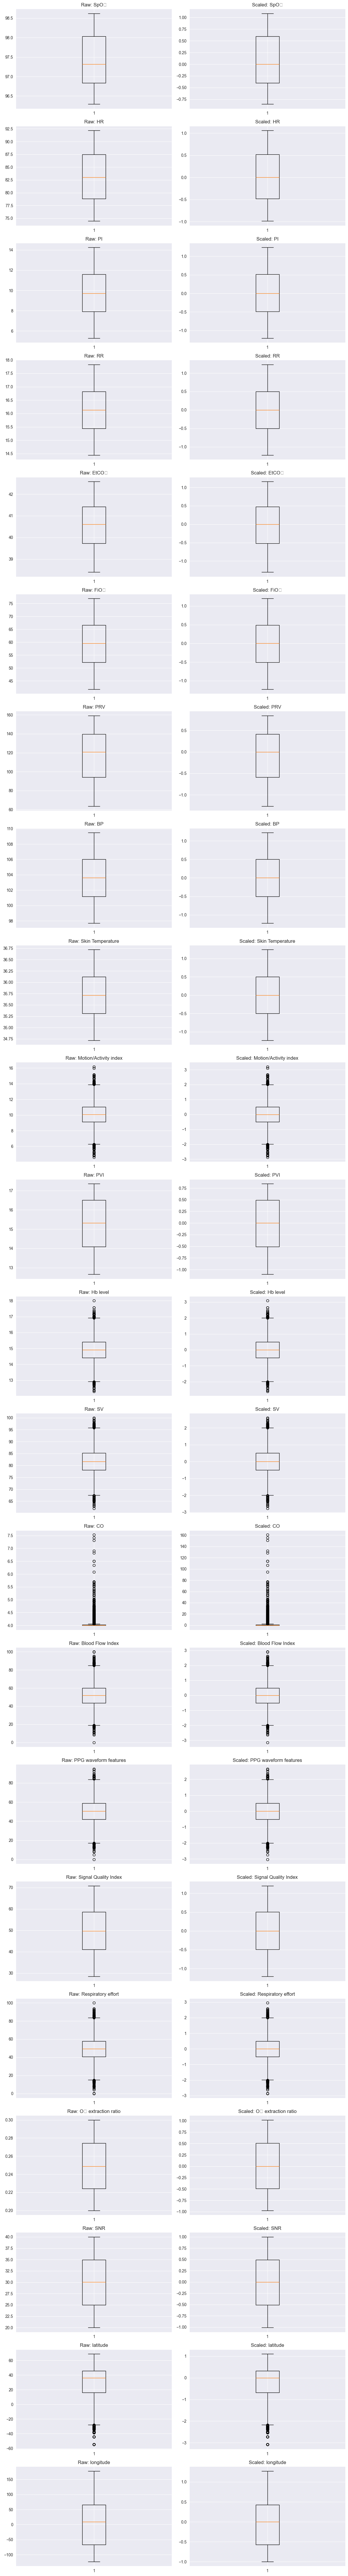

In [38]:
from math import ceil

# ...existing code...

std_scaler = RobustScaler()
std_scaler.fit(X_train)
X_train_std = std_scaler.transform(X_train)

# Преобразуем обратно в DataFrame, чтобы сохранить имена колонок
X_train_std_df = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)

n_features = X_train.shape[1]
n_plots = n_features * 2  # для raw и scaled каждого признака
n_cols = 2
n_rows = ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.ravel()  # удобная одномерная индексация

for i, col in enumerate(X_train.columns):

    axes[2 * i].boxplot(X_train[col])
    axes[2 * i].set_title(f"Raw: {col}")

    axes[2 * i + 1].boxplot(X_train_std_df[col])
    axes[2 * i + 1].set_title(f"Scaled: {col}")

# Если остались лишние пустые оси (когда n_plots < n_rows*n_cols), скрыть их
for j in range(2 * n_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


/var/folders/xz/3v1v24g13cz6t_6ww4mc5vzw0000gn/T/ipykernel_86456/2995596670.py:32: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/frtndmd/Desktop/iau_Kosharova_Oliinyk_67/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


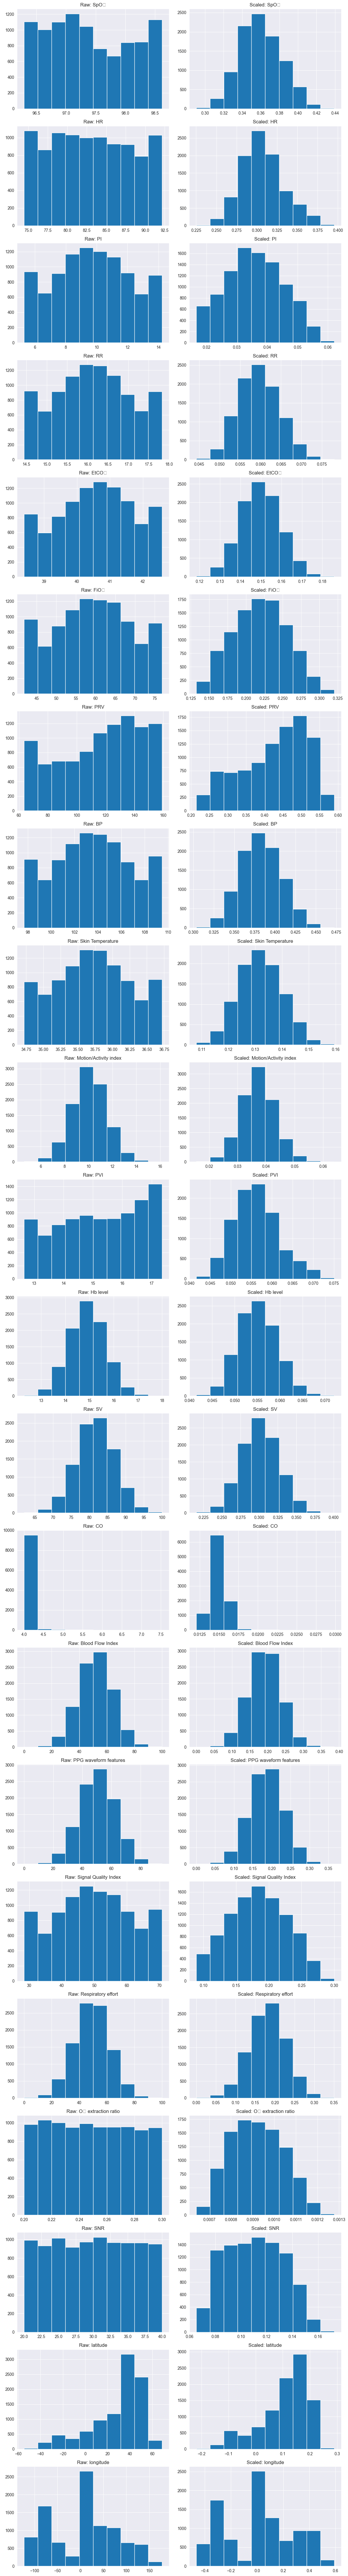

In [39]:
from math import ceil

# ...existing code...

std_scaler = Normalizer()
std_scaler.fit(X_train)
X_train_std = std_scaler.transform(X_train)

# Преобразуем обратно в DataFrame, чтобы сохранить имена колонок
X_train_std_df = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)

n_features = X_train.shape[1]
n_plots = n_features * 2  # для raw и scaled каждого признака
n_cols = 2
n_rows = ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.ravel()  # удобная одномерная индексация

for i, col in enumerate(X_train.columns):

    axes[2 * i].hist(X_train[col])
    axes[2 * i].set_title(f"Raw: {col}")

    axes[2 * i + 1].hist(X_train_std_df[col])
    axes[2 * i + 1].set_title(f"Scaled: {col}")

# Если остались лишние пустые оси (когда n_plots < n_rows*n_cols), скрыть их
for j in range(2 * n_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


/var/folders/xz/3v1v24g13cz6t_6ww4mc5vzw0000gn/T/ipykernel_86456/3681230708.py:32: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/frtndmd/Desktop/iau_Kosharova_Oliinyk_67/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


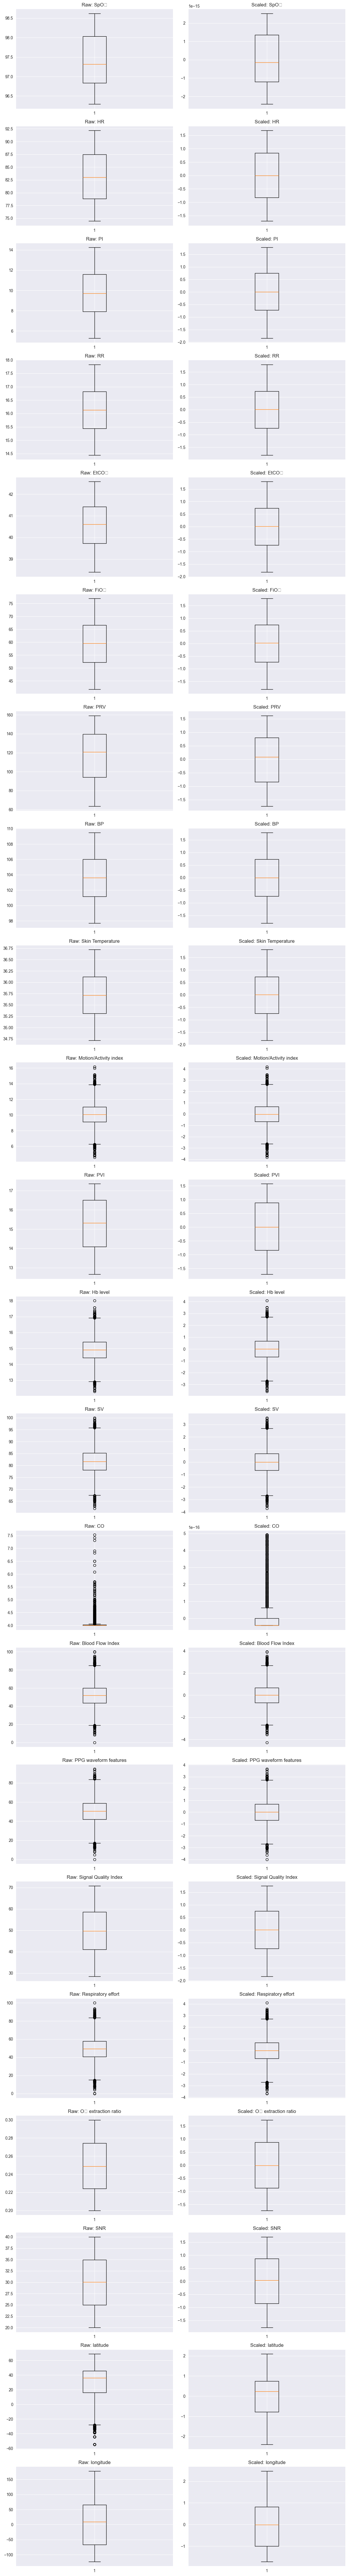

In [40]:
from math import ceil

# ...existing code...

std_scaler = PowerTransformer()
std_scaler.fit(X_train)
X_train_std = std_scaler.transform(X_train)

# Преобразуем обратно в DataFrame, чтобы сохранить имена колонок
X_train_std_df = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)

n_features = X_train.shape[1]
n_plots = n_features * 2  # для raw и scaled каждого признака
n_cols = 2
n_rows = ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.ravel()  # удобная одномерная индексация

for i, col in enumerate(X_train.columns):

    axes[2 * i].boxplot(X_train[col])
    axes[2 * i].set_title(f"Raw: {col}")

    axes[2 * i + 1].boxplot(X_train_std_df[col])
    axes[2 * i + 1].set_title(f"Scaled: {col}")

# Если остались лишние пустые оси (когда n_plots < n_rows*n_cols), скрыть их
for j in range(2 * n_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
